**STUDENT: Joel S. Mollel**

**NUMBER: C00313599**

**ALGORITHM: K-Means**

We are provided with code that performs clustering on the handwritten digits dataset using the K-Means algorithm, grouping them into 10 clusters, corresponding to the 10 digit classes. We are required to make the notebook work and test the characteristics of the K-Means Algorithm. We are also required to change the dataset and make adjustments to the given code to work with our new dataset.

We are required to:

    i) Make sure the code runs

    ii) Change some parameters on a given notebook and see the impact on the clustering process

    iii) Use another dataset and perform other operations, and simulate as an app

    Look at the changelog below to see the summary of what I did

| SN  | Change Made                                                | Reason                                                     | Time Taken               |
|-----|------------------------------------------------------------|------------------------------------------------------------|--------------------------|
| 1   | Made the code run by installing required libraries         | Ensure the code runs successfully                          | Approximately 10 minutes  |
| 2   | Changed number of clusters from 10 to 8                    | To observe the impact on clustering                         | Approximately 10 minutes  |
| 3   | Replaced Digits dataset with Iris dataset                  | To work with a new dataset (Iris for flower species)        | Approximately 10 minutes  |
| 4   | Replaced `digits.data` and `digits.target` with `iris.data` and `iris.target` | Iris dataset structure required adjustments               | Approximately 1 hour      |
| 5   | Adjusted number of clusters from 10 to 3                   | To match the 3 distinct flower species (Setosa, Versicolor, Virginica) | Approximately 10 minutes  |
| 6   | Removed visualization code for KMeans cluster centers using `imshow()` | Original code was designed for image data, not applicable to Iris dataset | Approximately 10 minutes  |
| 7   | Replaced the loop for 10 clusters with a loop for 3 clusters | To match the new Iris dataset clusters                     | Approximately 10 minutes  |
| 8   | Added user input for flower features (sepal and petal dimensions) | To predict flower type based on user input                 | Approximately 10 minutes  |
| 9   | Added prediction for new flower based on user input        | To predict flower species from the user-provided data      | Approximately 2 hours     |
| 10  | Used `iris.target_names` for predicted cluster labeling    | To show user-friendly feedback with flower names           | Approximately 50 minutes  |
| 11  | Added print statements for user feedback on predicted flower type | To give user feedback on predicted flower species          | Part of above (Time varies) |


***Part A: Working with Given Code ***

**(i) Making it work**

    The code ran well after installing all the required libraries.

0.7440178074568725

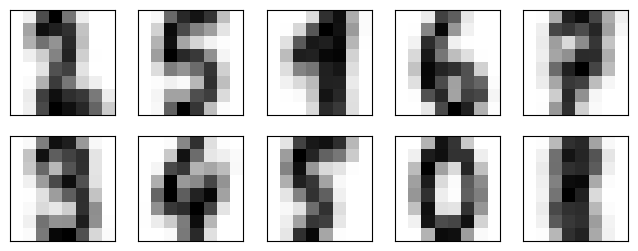

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import load_digits
digits = load_digits()
digits.data.shape
kmeans = KMeans(n_clusters=10, random_state=0)
clusters = kmeans.fit_predict(digits.data)
kmeans.cluster_centers_.shape
fig, ax = plt.subplots(2, 5, figsize=(8, 3))
centers = kmeans.cluster_centers_.reshape(10, 8, 8)
for axi, center in zip(ax.flat, centers):
    axi.set(xticks=[], yticks=[])
    axi.imshow(center, interpolation='nearest', cmap=plt.cm.binary)
from scipy.stats import mode
labels = np.zeros_like(clusters)
for i in range(10):
    mask = (clusters == i)
    labels[mask] = mode(digits.target[mask])[0]
from sklearn.metrics import accuracy_score
accuracy_score(digits.target, labels)

**(ii) Change some parameters and see the impact**

In this case, I changed the number of clusters from 10 to 8. Accuracy dropped from 0.7440 to 0.6466, suggesting that it is not a good cluster size for the numbers provided.

0.6466332776850306

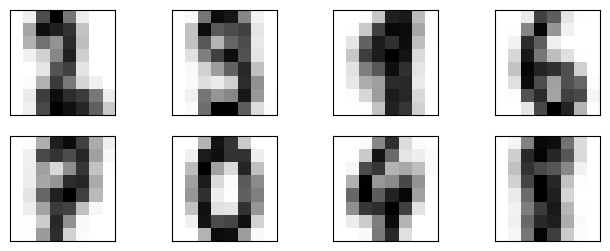

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import load_digits
digits = load_digits()
kmeans = KMeans(n_clusters=8, random_state=0) # Adjusted number of clusters to 8
clusters = kmeans.fit_predict(digits.data)
fig, ax = plt.subplots(2, 4, figsize=(8, 3)) # Adjusted for 8 clusters
centers = kmeans.cluster_centers_.reshape(8, 8, 8) # Adjusted for 8 clusters
for axi, center in zip(ax.flat, centers):
    axi.set(xticks=[], yticks=[])
    axi.imshow(center, interpolation='nearest', cmap=plt.cm.binary)
from scipy.stats import mode
labels = np.zeros_like(clusters)
for i in range(8): # Adjusted for 8 clusters
    mask = (clusters == i)
    labels[mask] = mode(digits.target[mask])[0]
from sklearn.metrics import accuracy_score # Calculate the accuracy score
accuracy_score(digits.target, labels)


***Part B: Working with Another Dataset***

I will use the Iris dataset. The Iris dataset consists of 150 samples from three iris flower species: Setosa, Versicolor, and Virginica. Each sample has four features—sepal length, sepal width, petal length, and petal width—measured in centimeters. The label values will therefore be Setosa, Versicolor, and Virginica.


**(i) Model training and testing accuracy**

**STEPS**

**Step 1: Loading libraries and Iris dataset**

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score
from scipy.stats import mode
iris = load_iris()
iris_data = iris.data
iris_target = iris.target

**Step 2: Printing 5 rows of data to see the structure The label values are as follows:**

    0 = Setosa

    1 = Versicolor

    2 = Virginica

In [7]:
import pandas as pd
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)
iris_df['label'] = iris.target
print(iris_df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   label  
0      0  
1      0  
2      0  
3      0  
4      0  


**Step 3: Performing clustering**

In [8]:
kmeans = KMeans(n_clusters=3, random_state=0)
clusters = kmeans.fit_predict(iris_data)

**Step 4: Visualize how datapoints are distributed for each flower cluster**

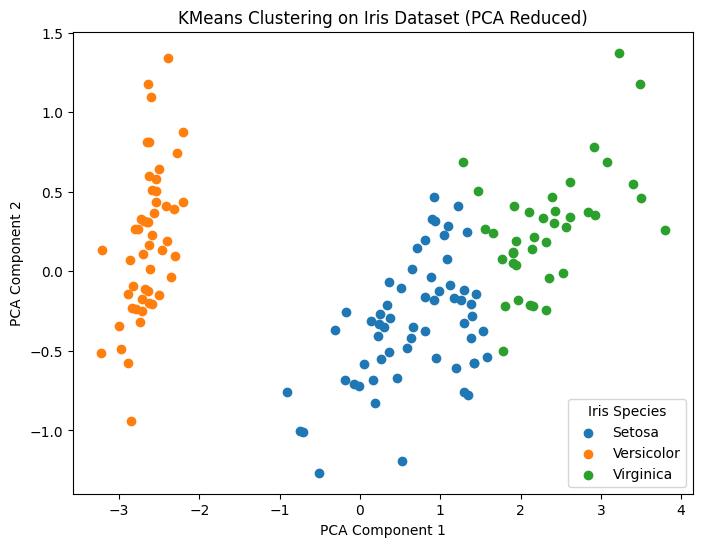

In [10]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
pca = PCA(n_components=2)
reduced_data = pca.fit_transform(iris_data)
cluster_names = ['Setosa', 'Versicolor', 'Virginica']
plt.figure(figsize=(8, 6))
for i, name in enumerate(cluster_names):
    mask = clusters == i
    plt.scatter(reduced_data[mask, 0], reduced_data[mask, 1], label=name)
    plt.title('KMeans Clustering on Iris Dataset (PCA Reduced)') #title and axis labels
    plt.xlabel('PCA Component 1')
    plt.ylabel('PCA Component 2')
    # JM: Add a legend to map clusters to species names
    plt.legend(title="Iris Species")
    # JM: Display the plot
plt.show()

**ii) Flower Prediction System**

The system is designed to use the K-Means algorithm to predict flower type based on user input. Run the code below to use the system. The difference between this code and the above one is just some lines for prompting and processing the user input.

In [11]:
## from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from scipy.stats import mode

iris = load_iris()
iris_data = iris.data
iris_target = iris.target

kmeans = KMeans(n_clusters=3, random_state=0)
clusters = kmeans.fit_predict(iris_data)

labels = np.zeros_like(clusters)
for i in range(3):
    mask = (clusters == i)
    labels[mask] = mode(iris_target[mask], axis=None)[0]

# Prompting the user to enter the flower features 
print("Enter the values for the following features of the flower you want to identify (in cm):")
sepal_length = float(input("Sepal length (cm): "))
sepal_width = float(input("Sepal width (cm): "))
petal_length = float(input("Petal length (cm): "))
petal_width = float(input("Petal width (cm): "))

# Create a new data point based on user input
new_flower = np.array([[sepal_length, sepal_width, petal_length, petal_width]])

# Actual prediction occurs here
predicted_cluster = kmeans.predict(new_flower)[0]

predicted_flower_name = iris.target_names[mode(iris_target[clusters == predicted_cluster], axis=None)[0]]

# Display the result
print(f"The predicted flower type is: {predicted_flower_name.capitalize()}")


Enter the values for the following features of the flower you want to identify (in cm):


Sepal length (cm):  2
Sepal width (cm):  2
Petal length (cm):  2
Petal width (cm):  2


The predicted flower type is: Setosa


***CONCLUSION***

Learning the implementation of K-Means was not very difficult, especially starting from the given code. The sources touched upon its strength in image processing, but I did not get the real-life dataset to try. I will definitely use it in my future practicals to cluster real-life images.


***REFERENCES***

VanderPlas, J. (2016). *K-Means. GitHub repository*, available at: https://github.com/jakevdp/PythonDataScienceHandbook/blob/master/notebooks/05.11-K-Means.ipynb [Accessed 6 Feb. 2025].

Scikit-learn. (2025). *Iris dataset. Scikit-learn*, available at: https://scikit-learn.org/stable/auto_examples/datasets/plot_iris_dataset.html [Accessed 6 Feb. 2025].